# Apertus vs Llama activation analysis (expanded)

This notebook runs a larger token-level activation analysis for **Apertus** and **Llama**.

It now:
- collects more samples/tokens,
- evaluates the requested layer set: **[4, 10, 16, 20, 24, 26, 28, 30]**,
- plots PCA projections for each layer and model,
- computes multiple separation metrics (silhouette, centroid distances, Fisher ratio, linear probe AUC/ACC, KMeans ARI/NMI).

In [30]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA


import importlib
import sys
sys.path.insert(0, str((Path().resolve().parent).resolve()))

import utils.activation_analysis as activation_analysis
activation_analysis = importlib.reload(activation_analysis)

import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

COLORS        = {"apertus": "#E07B39", "llama": "#3B82C4"}
MODEL_DISPLAY = {"apertus": "Apertus-8B-Instruct-2509", "llama": "Llama-3.1-8B-Instruct"}
NOTE_COLOR    = "#888888"
NOTE_SIZE     = 9


build_metrics_table      = activation_analysis.build_metrics_table
build_pca_plot_frame     = activation_analysis.build_pca_plot_frame
summarize_collection_counts = activation_analysis.summarize_collection_counts

sns.set_theme(style="whitegrid", palette="muted")

ACTIVATIONS_DIR = Path("../outputs/activations")
TARGET_LAYERS   = [4, 10, 16, 20, 24, 26, 28, 30]
SEED            = 42


In [26]:
def load_sweep(out_dir: Path) -> dict:
    sweep = {}
    for model_dir in sorted(out_dir.iterdir()):
        if not model_dir.is_dir():
            continue
        meta = json.loads((model_dir / "meta.json").read_text())
        per_layer = {}
        for layer in meta["layers"]:
            layer_dir = model_dir / f"layer_{layer:02d}"
            per_layer[layer] = {
                "positive": np.load(layer_dir / "positive.npy"),
                "negative": np.load(layer_dir / "negative.npy"),
            }
        sweep[meta["model_key"]] = {**meta, "per_layer": per_layer}
    return sweep

fair_sweep  = load_sweep(ACTIVATIONS_DIR / "fair")
raw_sweep   = load_sweep(ACTIVATIONS_DIR / "raw")
norm_df     = pd.read_csv(ACTIVATIONS_DIR / "norm_stats.csv")
counts_df   = summarize_collection_counts(fair_sweep, TARGET_LAYERS)

print("Loaded models:", list(fair_sweep.keys()))
display(counts_df)


Loaded models: ['apertus', 'llama']


,model,layer,hallucinated_tokens,supported_tokens,hidden_dim
0,apertus,4,30000,30000,4096
1,apertus,10,30000,30000,4096
2,apertus,16,30000,30000,4096
3,apertus,20,30000,30000,4096
4,apertus,24,30000,30000,4096
5,apertus,26,30000,30000,4096
6,apertus,28,30000,30000,4096
7,apertus,30,30000,30000,4096
8,llama,4,30000,30000,4096
9,llama,10,30000,30000,4096


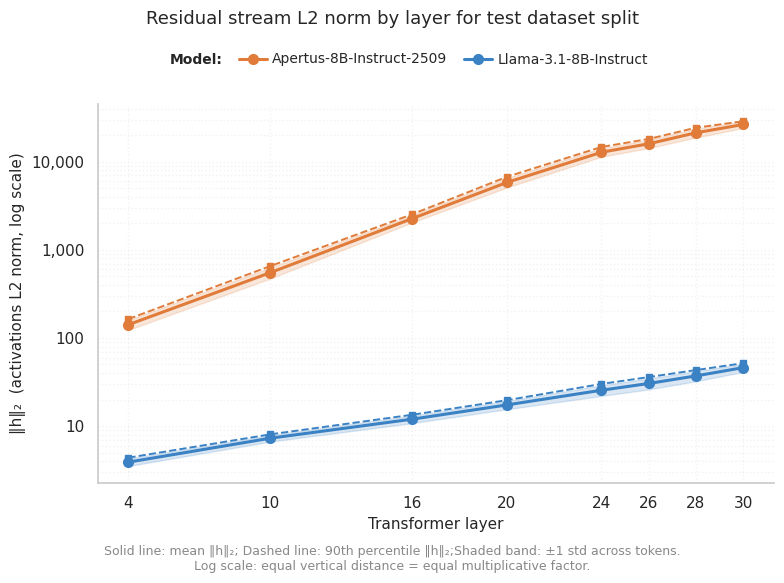

In [33]:
fig, ax = plt.subplots(figsize=(8, 5.0))

for model_key in ["apertus", "llama"]:
    cur = norm_df[norm_df["model"] == model_key]
    agg = cur.groupby("layer")[["norm_mean", "norm_std", "norm_p90"]].mean().reset_index()
    c   = COLORS[model_key]

    ax.fill_between(
        agg["layer"],
        agg["norm_mean"] - agg["norm_std"],
        agg["norm_mean"] + agg["norm_std"],
        color=c, alpha=0.18, zorder=1,
    )
    ax.plot(agg["layer"], agg["norm_mean"],
            color=c, marker="o", linewidth=2.2, markersize=7,
            label=MODEL_DISPLAY[model_key], zorder=3)
    ax.plot(agg["layer"], agg["norm_p90"],
            color=c, marker="s", linestyle="--", linewidth=1.4, markersize=5,
            zorder=3, label="_nolegend_")

ax.set_yscale("log")
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda v, _: f"{v:,.0f}" if v >= 1 else f"{v:.2f}")
)
ax.set_xticks(agg["layer"].tolist())
ax.set_xlabel("Transformer layer", fontsize=11)
ax.set_ylabel("‖h‖₂  (activations L2 norm, log scale)", fontsize=11)
ax.grid(True, which="both", linestyle=":", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

# ── legend: model colours only, matching plot_layer_metrics style ────────────
handles, labels = ax.get_legend_handles_labels()
title_handle    = Patch(visible=False)

legend = fig.legend(
    [title_handle] + handles,
    ["Model:"] + labels,
    loc="upper center",
    ncol=len(labels) + 1,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
    columnspacing=1.2,
    handlelength=2,
    handletextpad=0.4,
    fontsize=10,
)
legend.get_texts()[0].set_fontweight("bold")

fig.suptitle(
    "Residual stream L2 norm by layer for test dataset split",
    fontsize=13, y=1.08,
)
fig.text(
    0.5, -0.04,
    "Solid line: mean ‖h‖₂; Dashed line: 90th percentile ‖h‖₂;"
    "Shaded band: ±1 std across tokens.\n"
    "Log scale: equal vertical distance = equal multiplicative factor.",
    ha="center", fontsize=NOTE_SIZE, color=NOTE_COLOR,
)

fig.tight_layout(rect=(0, 0, 1, 1))
fig.savefig("activation_norms.png", dpi=150, bbox_inches="tight")
plt.show()

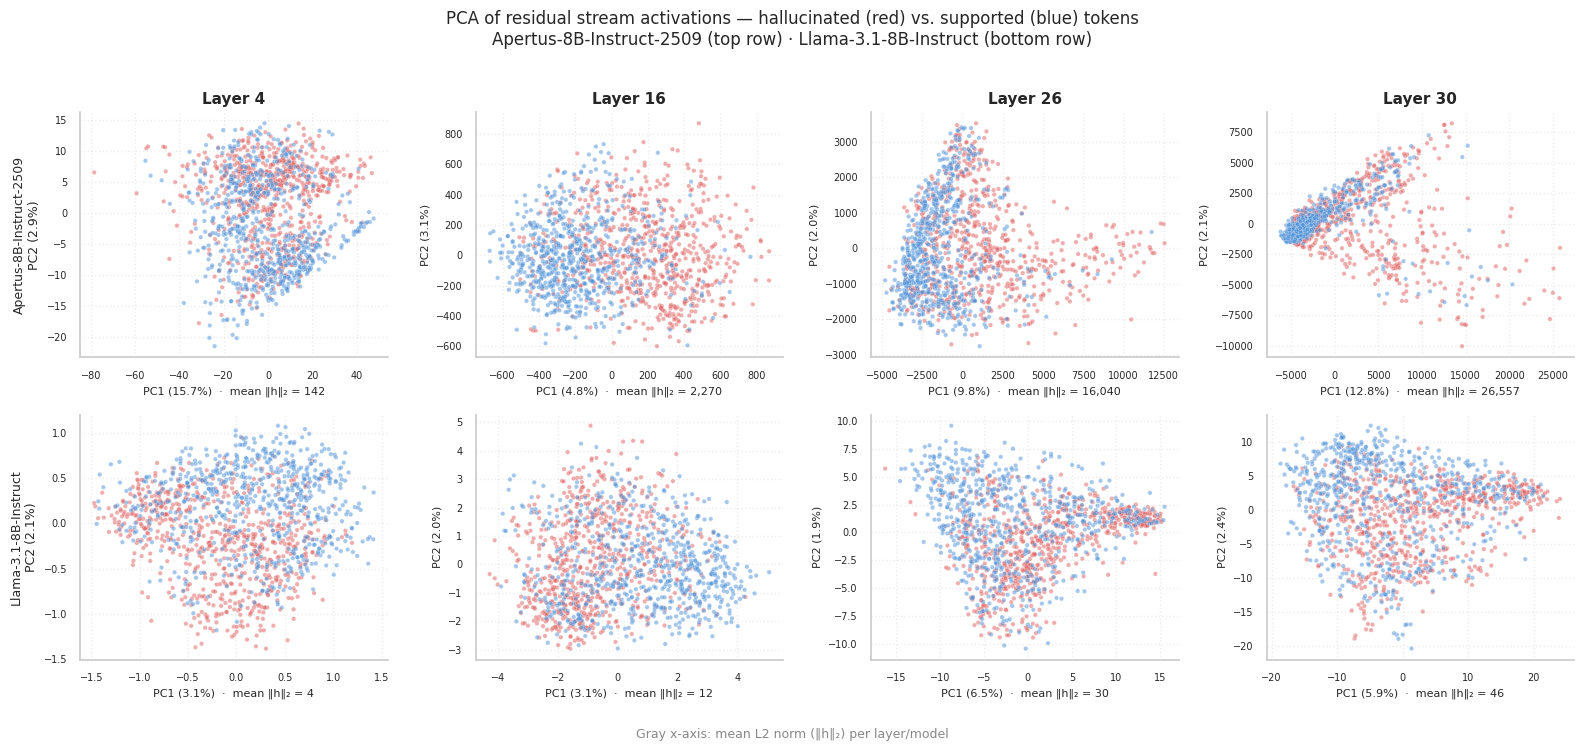

In [34]:
# PCA scatter plots: split rows by model, hallucination classification in red/blue, improved caption
HIGHLIGHT_LAYERS = [4, 16, 26, 30]

# Red/blue for hallucination classification
PALETTE = {"Hallucinated": "#e05c5c", "Supported": "#4a90d9"}
MODEL_DISPLAY = {"apertus": "Apertus-8B-Instruct-2509", "llama": "Llama-3.1-8B-Instruct"}

fig, axes = plt.subplots(2, len(HIGHLIGHT_LAYERS), figsize=(16, 7), sharex=False, sharey=False)

for row_idx, model_key in enumerate(["apertus", "llama"]):
    for col_idx, layer in enumerate(HIGHLIGHT_LAYERS):
        ax = axes[row_idx][col_idx]
        cur = pca_df[(pca_df["layer"] == layer) & (pca_df["model"] == model_key)]
        if cur.empty:
            ax.set_visible(False)
            continue
        sns.scatterplot(
            data=cur, x="pc1", y="pc2", hue="label", palette=PALETTE, alpha=0.5, s=10, ax=ax, legend=False
        )
        v1 = cur["pc1_var"].iloc[0] if not cur.empty else 0
        v2 = cur["pc2_var"].iloc[0] if not cur.empty else 0
        mean_norm = norm_lookup.get((model_key, layer), float("nan"))
        # column header: layer number (top row only)
        if row_idx == 0:
            ax.set_title(f"Layer {layer}", fontsize=11, fontweight="bold")
        # row label: full model name (left column only)
        if col_idx == 0:
            ax.set_ylabel(f"{MODEL_DISPLAY[model_key]}\nPC2 ({v2:.1%})", fontsize=9)
        else:
            ax.set_ylabel(f"PC2 ({v2:.1%})", fontsize=8)
        # x-axis carries variance explained + mean norm so scale is always visible
        ax.set_xlabel(f"PC1 ({v1:.1%})  ·  mean ‖h‖₂ = {mean_norm:,.0f}", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(True, which="both", linestyle=":", alpha=0.35)

# Add legend only once
handles, labels = axes[0][0].get_legend_handles_labels()
if handles:
    axes[0][0].legend(handles, ["Hallucinated", "Supported"], fontsize=9, loc="upper right", framealpha=0.92, title="Token label")

fig.suptitle("PCA of residual stream activations — hallucinated (red) vs. supported (blue) tokens\nApertus-8B-Instruct-2509 (top row) · Llama-3.1-8B-Instruct (bottom row)", fontsize=12, y=1.01)
fig.text(0.5, -0.03, "Gray x-axis: mean L2 norm (‖h‖₂) per layer/model", ha="center", fontsize=9, color="#888")
fig.tight_layout()

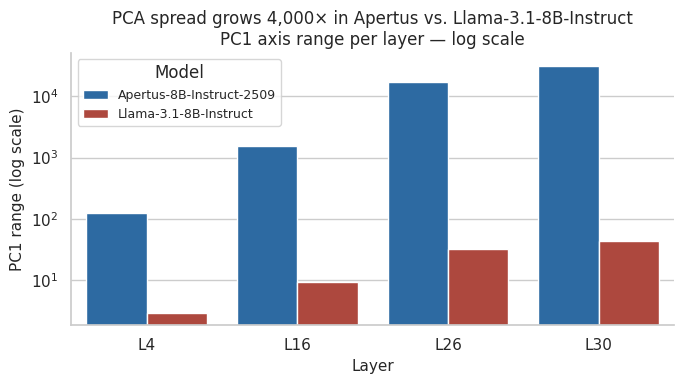

In [20]:
# After building pca_df, compute the axis range per model/layer
range_rows = []
for model_key in ["apertus", "llama"]:
    for layer in HIGHLIGHT_LAYERS:
        cur = pca_df[(pca_df["layer"] == layer) & (pca_df["model"] == model_key)]
        if cur.empty:
            continue
        range_rows.append({
            "model": MODEL_DISPLAY[model_key],
            "layer": f"L{layer}",
            "pc1_range": cur["pc1"].max() - cur["pc1"].min(),
        })

range_df = pd.DataFrame(range_rows)

fig_r, ax_r = plt.subplots(figsize=(7, 4))
sns.barplot(data=range_df, x="layer", y="pc1_range", hue="model",
            palette={"Apertus-8B-Instruct-2509": "#1a6bb5",
                     "Llama-3.1-8B-Instruct": "#c0392b"},
            ax=ax_r)
ax_r.set_yscale("log")
ax_r.set_ylabel("PC1 range (log scale)", fontsize=11)
ax_r.set_xlabel("Layer", fontsize=11)
ax_r.set_title(
    "PCA spread grows 4,000× in Apertus vs. Llama-3.1-8B-Instruct\n"
    "PC1 axis range per layer — log scale",
    fontsize=12
)
ax_r.spines[["top", "right"]].set_visible(False)
ax_r.legend(title="Model", fontsize=9)
fig_r.tight_layout()
fig_r.savefig("pca_range_comparison.png", dpi=150, bbox_inches="tight")


NameError: name 'NOTE_COLOR' is not defined

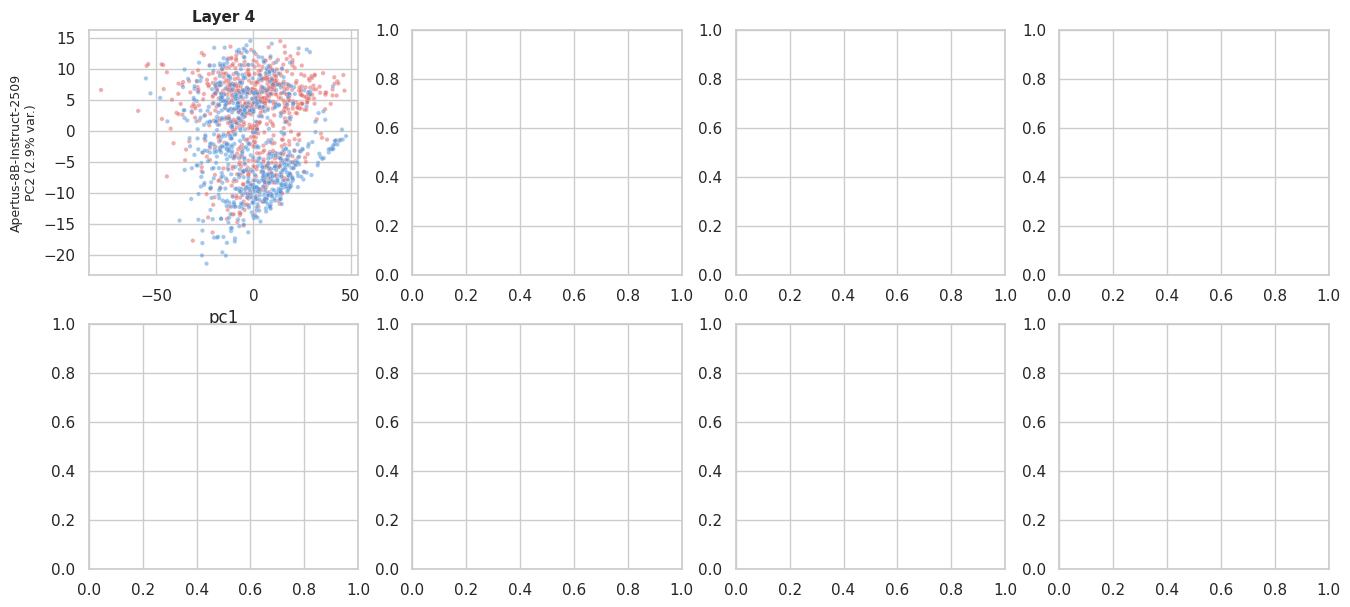

In [24]:

HIGHLIGHT_LAYERS = [4, 16, 26, 30]
PALETTE          = {"Hallucinated": "#e05c5c", "Supported": "#4a90d9"}

pca_df = build_pca_plot_frame(
    fair_sweep, HIGHLIGHT_LAYERS, max_points_per_label=700, seed=SEED
)
norm_lookup = (
    norm_df.groupby(["model", "layer"])["norm_mean"]
    .mean()
    .to_dict()
)

fig, axes = plt.subplots(2, len(HIGHLIGHT_LAYERS), figsize=(16, 7),
                         sharex=False, sharey=False)

for row_idx, model_key in enumerate(["apertus", "llama"]):
    for col_idx, layer in enumerate(HIGHLIGHT_LAYERS):
        ax = axes[row_idx][col_idx]
        cur = pca_df[(pca_df["layer"] == layer) & (pca_df["model"] == model_key)]

        if cur.empty:
            ax.set_visible(False)
            continue

        sns.scatterplot(
            data=cur, x="pc1", y="pc2", hue="label",
            palette=PALETTE, alpha=0.5, s=10, ax=ax, legend=False,
        )

        v1        = cur["pc1_var"].iloc[0]
        v2        = cur["pc2_var"].iloc[0]
        mean_norm = norm_lookup.get((model_key, layer), float("nan"))

        if row_idx == 0:
            ax.set_title(f"Layer {layer}", fontsize=11, fontweight="bold")

        if col_idx == 0:
            ax.set_ylabel(
                f"{MODEL_DISPLAY[model_key]}\nPC2 ({v2:.1%} var.)", fontsize=9,
            )
        else:
            ax.set_ylabel(f"PC2 ({v2:.1%} var.)", fontsize=8)

        ax.set_xlabel(
            f"PC1 ({v1:.1%} var.)  ·  mean ‖h‖₂ = {mean_norm:,.0f}",
            fontsize=8, color=NOTE_COLOR,
        )
        ax.tick_params(labelsize=7)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(True, linestyle=":", alpha=0.35)

# ── single legend for scatter colours ───────────────────────────────────────
scatter_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#e05c5c",
           markersize=8, label="Hallucinated — token annotated as not supported by evidence"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4a90d9",
           markersize=8, label="Supported — token annotated as factually correct"),
]
title_handle = Patch(visible=False)

legend = fig.legend(
    [title_handle] + scatter_handles,
    ["Token label:"] + [h.get_label() for h in scatter_handles],
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
    fontsize=9.5,
    handlelength=1.2,
    handletextpad=0.5,
    columnspacing=1.5,
)
legend.get_texts()[0].set_fontweight("bold")

fig.suptitle(
    "PCA of residual stream activations — hallucinated (red) vs. supported (blue) tokens\n"
    "Apertus-8B-Instruct-2509 (top) · Llama-3.1-8B-Instruct (bottom) · "
    "independent axes per panel",
    fontsize=12, y=1.01,
)
fig.text(
    0.5, -0.08,
    "Note: PCA fitted independently per panel on 700 tokens per class (1:1 ratio, equalized across models).  "
    "PC1/PC2 variance explained and mean ‖h‖₂ shown in axis labels.  "
    "Overlapping clusters indicate low probe separability; spread clusters indicate high separability.  "
    "Axis scale reflects absolute activation magnitude — compare x-axis ranges across Apertus panels.",
    ha="center", fontsize=NOTE_SIZE, color=NOTE_COLOR, wrap=True,
)

fig.tight_layout()
fig.savefig("pca_highlight.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Heatmaps: improved style, better grid
pivot_sil = metrics_df.pivot(index="layer", columns="model", values="silhouette_pca10")
pivot_auc = metrics_df.pivot(index="layer", columns="model", values="linear_probe_auc_pca20")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

sns.heatmap(
    pivot_sil, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=-0.1, vmax=0.4, ax=axes[0], linewidths=0.7, linecolor="#e0e0e0", cbar=False
)
axes[0].set_title("Silhouette score (PCA-10)\nhigher = better separated", fontsize=11)
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Layer")

sns.heatmap(
    pivot_auc, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0.45, vmax=0.85, ax=axes[1], linewidths=0.7, linecolor="#e0e0e0", cbar=True
)
axes[1].set_title("Linear probe AUC (PCA-20)\nhigher = more linearly separable", fontsize=11)
axes[1].set_xlabel("Model")
axes[1].set_ylabel("")

fig.suptitle("Separation metrics by layer — Apertus vs. Llama", fontsize=13)
plt.show()